# Coordinate transformations with OMNI data

**By Eric Grimes, UCLA - Earth, Planetary, and Space Sciences; egrimes(at)igpp.ucla.edu**

This notebook shows how to load OMNI data, combine the B-field components into a single variable, then use `cotrans` to transform the data to GSM coordinates, and finally plot the B-field in GSE and GSM coordinates

The following line installs pyspedas, so this notebook can be used in Google Colab.  If you're running in an environment where pyspedas is already installed, you can comment out or skip this command.

In [12]:
!pip install pyspedas

18-Dec-25 12:38:59: /Users/jwl/anaconda3/envs/pycharm_py312/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=7771) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



In [13]:
import pyspedas

Load some OMNI data; we'll transform the B-field from GSE coordinates to GSM coordinates

In [14]:
pyspedas.projects.omni.data(trange=['2015-10-16', '2015-10-17'])

18-Dec-25 12:39:01: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2015/
18-Dec-25 12:39:02: File is current: omni_data/hro_1min/2015/omni_hro_1min_20151001_v01.cdf


['IMF',
 'PLS',
 'IMF_PTS',
 'PLS_PTS',
 'percent_interp',
 'Timeshift',
 'RMS_Timeshift',
 'RMS_phase',
 'Time_btwn_obs',
 'F',
 'BX_GSE',
 'BY_GSE',
 'BZ_GSE',
 'BY_GSM',
 'BZ_GSM',
 'RMS_SD_B',
 'RMS_SD_fld_vec',
 'flow_speed',
 'Vx',
 'Vy',
 'Vz',
 'proton_density',
 'T',
 'Pressure',
 'E',
 'Beta',
 'Mach_num',
 'Mgs_mach_num',
 'x',
 'y',
 'z',
 'BSN_x',
 'BSN_y',
 'BSN_z',
 'AE_INDEX',
 'AL_INDEX',
 'AU_INDEX',
 'SYM_D',
 'SYM_H',
 'ASY_D',
 'ASY_H',
 'PC_N_INDEX']

The B-field components are stored as separate variables; to transform them using `cotrans`, we'll need to combine them into a single variable. We'll use `join_vec` from `pyspedas` to do this:

In [15]:
from pyspedas import join_vec

join_vec(['BX_GSE', 'BY_GSE', 'BZ_GSE'], newname='B_GSE')

'B_GSE'

Now we can transform `B_GSE` to GSM coordinates using `cotrans`

In [16]:
from pyspedas import cotrans

cotrans(name_in='B_GSE', name_out='B_GSM', coord_in='gse', coord_out='gsm')

18-Dec-25 12:39:03: ['gse', 'gsm']
18-Dec-25 12:39:03: Running transformation: subgse2gsm
18-Dec-25 12:39:03: Setting coordinate system for B_GSM
18-Dec-25 12:39:03: Output variable: B_GSM


1

Set some plot metadata on our new variables

In [17]:
from pyspedas import options

options('B_GSE', 'ytitle', 'OMNI B-field')
options('B_GSE', 'ysubtitle', '[nT]')
options('B_GSE', 'legend_names', ['Bx GSE', 'By GSE', 'Bz GSE'])

options('B_GSM', 'ytitle', 'OMNI B-field')
options('B_GSM', 'ysubtitle', '[nT]')
options('B_GSM', 'legend_names', ['Bx GSM', 'By GSM', 'Bz GSM'])

Now we can plot the B-field in GSE and GSM coordinates

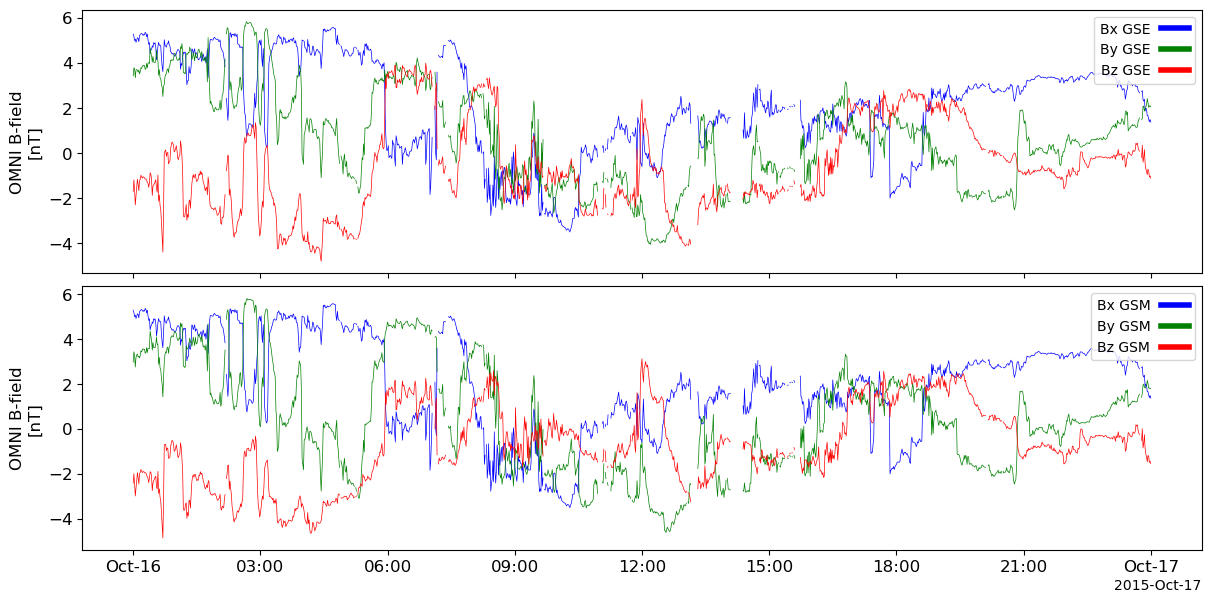

In [18]:
from pyspedas import tplot

tplot(['B_GSE', 'B_GSM'])